## Task 1:-Prepare a complete data analysis report on the given data.

 ***Problem Statement***
- The objective of this project is to analyze the FIFA dataset to understand player characteristics and identify key factors influencing a player’s overall rating. Exploratory Data Analysis (EDA) is performed to uncover patterns and relationships, followed by data preprocessing to prepare the data for machine learning models. Finally, predictive models are developed and evaluated to estimate player performance.


***Dataset Overview***
- Dataset: FIFA Players (players_20.csv)
- Number of records: 18278 players
- Number of features: 104 attributes
- Data types:
- Numerical: age, overall, potential, wage_eur, value_eur, skill ratings
- Categorical: nationality, club, preferred_foot, player_positions
- The dataset represents professional footballers playing at an international level.


***Initial Data Inspection***

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

***Loading the dataset of FIFA***

In [86]:
df = pd.read_csv("data/players_20.csv")
df.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3


***Insight***
- The dataset contains professional football player data including demographics, skills, and financial attributes.

In [87]:
#Return no. of rows and columns
df.shape

(18278, 104)

- Dataset contains 18278 players and 104 features

In [88]:
#Provide Datatypes, Non-null count and Memory uses
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Columns: 104 entries, sofifa_id to rb
dtypes: float64(16), int64(45), str(43)
memory usage: 19.1 MB


- Data includes numerical, categorical, and ordinal attributes

In [89]:
# Give Statistical summary of numerical features
df.describe()

,sofifa_id,age,height_cm,weight_kg,overall,potential,value_eur,wage_eur,international_reputation,weak_foot,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
count,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,1.827800e+04,18278.000000,18278.000000,18278.000000,...,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000
mean,219738.864482,25.283291,181.362184,75.276343,66.244994,71.546887,2.484038e+06,9456.942773,1.103184,2.944250,...,48.383357,58.528778,46.848889,47.640333,45.606631,16.572765,16.354853,16.212934,16.368038,16.709924
std,27960.200461,4.656964,6.756961,7.047744,6.949953,6.139669,5.585481e+06,21351.714095,0.378861,0.664656,...,15.708099,11.880840,20.091287,21.585641,21.217734,17.738069,16.996925,16.613665,17.136497,18.038125
min,768.000000,16.000000,156.000000,50.000000,48.000000,49.000000,0.000000e+00,0.000000,1.000000,1.000000,...,7.000000,12.000000,1.000000,5.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,204445.500000,22.000000,177.000000,70.000000,62.000000,67.000000,3.250000e+05,1000.000000,1.000000,3.000000,...,39.000000,51.000000,29.000000,27.000000,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,226165.000000,25.000000,181.000000,75.000000,66.000000,71.000000,7.000000e+05,3000.000000,1.000000,3.000000,...,49.000000,60.000000,52.000000,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,240795.750000,29.000000,186.000000,80.000000,71.000000,75.000000,2.100000e+06,8000.000000,1.000000,3.000000,...,60.000000,67.000000,64.000000,66.000000,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,252905.000000,42.000000,205.000000,110.000000,94.000000,95.000000,1.055000e+08,565000.000000,5.000000,5.000000,...,92.000000,96.000000,94.000000,92.000000,90.000000,90.000000,92.000000,93.000000,91.000000,92.000000


In [90]:
#Missing Value Analysis
missing = df.isnull().sum().sort_values(ascending=False)
missing.head(10)


loaned_from             17230
nation_position         17152
nation_jersey_number    17152
player_tags             16779
gk_kicking              16242
gk_diving               16242
gk_handling             16242
gk_reflexes             16242
gk_speed                16242
gk_positioning          16242
dtype: int64

***Insight***
- Columns like loaned_from, nation_position, nation_jersey_number have very high missing values
- Goalkeeper attributes are missing for non-GK players
- These missing values are expected and logical

In [91]:
df.drop(
    ['loaned_from','nation_position','nation_jersey_number'],
    axis=1,
    inplace=True,
    errors='ignore'
)

***Insight***
- Dropped low-utility columns (loaned_from, nation_position, nation_jersey_number) that contain many missing or non-predictive values to reduce noise and improve model performance.

In [92]:
# 1. Drop GK-specific columns
gk_cols = [c for c in df.columns if c.startswith('gk_')]
df.drop(columns=gk_cols, inplace=True, errors='ignore')

***Insight***
- Removed goalkeeper-specific features to keep the dataset consistent with outfield players, preventing irrelevant attributes from introducing noise into the model.

In [93]:
# 2. Drop high-missing text columns
df.drop(
    columns=['player_tags', 'player_traits'],
    inplace=True,
    errors='ignore'
)

***Insight***
- Dropped high-missing, unstructured text columns (player_tags, player_traits) to avoid sparsity and noise, ensuring the model focuses on reliable numerical features.

In [94]:
# 3. Fill position-based rating columns with 0
# (structural missing values)
position_cols = [
    'lf','lw','rw','rf',
    'cam','ram','lam',
    'cm','lcm','rcm',
    'cdm','rdm','ldm',
    'cb','lcb','rcb',
    'lb','lwb','rwb','rm'
]

***Insight***
- Filled position-specific rating columns with 0 to represent structural absence (player does not play that position), preserving information while avoiding misleading imputation.

In [95]:
# keep only columns that actually exist (prevents errors)
position_cols = [c for c in position_cols if c in df.columns]

df[position_cols] = df[position_cols].fillna(0)

***Insight***
- Ensured robustness by selecting only existing position columns and filling missing values with 0, accurately encoding non-applicable positions without introducing bias.

In [96]:
# 4. Fill numeric columns (except positions) with median
num_cols = df.select_dtypes(include='number').columns
num_cols = [c for c in num_cols if c not in position_cols]

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

***Insight***
- Imputed remaining numerical features with their median values (excluding position ratings) to handle missing data robustly while minimizing the impact of outliers.

In [97]:
# 5. Handle release clause (no clause = 0)
if 'release_clause_eur' in df.columns:
    df['release_clause_eur'] = df['release_clause_eur'].fillna(0)

***Insight***
- Filled missing release_clause_eur values with 0 to explicitly represent players without a release clause, preserving real-world meaning and avoiding misleading imputation.

In [98]:
# 6. Handle date column: joined
if 'joined' in df.columns:
    df['joined'] = pd.to_datetime(df['joined'], errors='coerce')
    df['joined'] = df['joined'].fillna(df['joined'].median())

***Insight***
- Converted the joined column to datetime and filled missing values with the median join date to retain temporal information while ensuring completeness for modeling.

In [99]:
# 7. Handle remaining categorical columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\91879\AppData\Local\Temp\ipykernel_19568\351359628.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


***Insight***
- Filled missing categorical values with the most frequent category (mode) to maintain consistency and prevent loss of information during model traini

In [100]:
# 8. Final check
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


***Insight***
- Missing values were handled using domain-specific logic—structural zeros for position ratings, median imputation for numeric attributes, and meaningful defaults for contract and date features—resulting in a clean, model-ready dataset.

***Univariate Analysis***
- Univariate Analysis (FIFA Dataset):
Univariate Analysis is the study of a single feature in the FIFA dataset to understand its distribution and characteristics. It helps to summarize information like player age, overall rating, or wage using statistics (mean, median, mode) and visualizations such as histograms, bar charts, or box plots, without considering relationships with other features

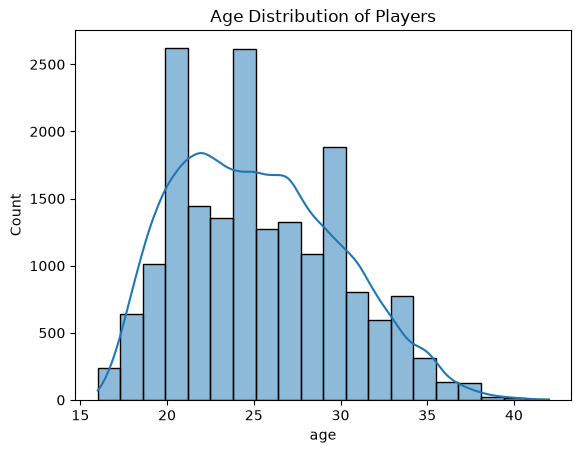

In [101]:
#Age Distribution
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution of Players')
plt.show()

***Insight***
- The histogram shows that most FIFA players are between 24 and 30 years old, indicating that the prime age for professional players is mid-20s to late 20s. There are relatively fewer very young (under 20) and older players (over 35), which suggests that teams tend to recruit players in their peak performance years. The distribution is slightly right-skewed, showing a small number of older players still active in the league

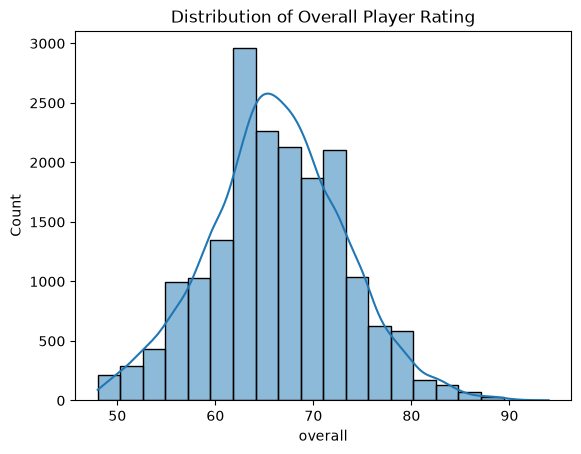

In [102]:
#Overall Rating Distribution
sns.histplot(df['overall'], bins=20, kde=True)
plt.title('Distribution of Overall Player Rating')
plt.show()

***Insight***
- The histogram shows that most players have an overall rating between 65 and 75, indicating that the majority of FIFA players fall in the average to above-average skill range. There are fewer players with very high ratings (85+) or very low ratings (<60), suggesting that elite players are rare, while most players are moderately skilled. The distribution is slightly left-skewed, highlighting that top-rated players are a small fraction of the total pool.

***Bivariate Analysis***
- Bivariate Analysis is the study of the relationship between two variables in the FIFA dataset. It helps to understand how one feature affects or relates to another, such as age vs. overall rating or wage vs. potential. This analysis uses visualizations like scatter plots, box plots, or correlation heatmaps and statistics like correlation coefficients to reveal patterns and trends between the two features.

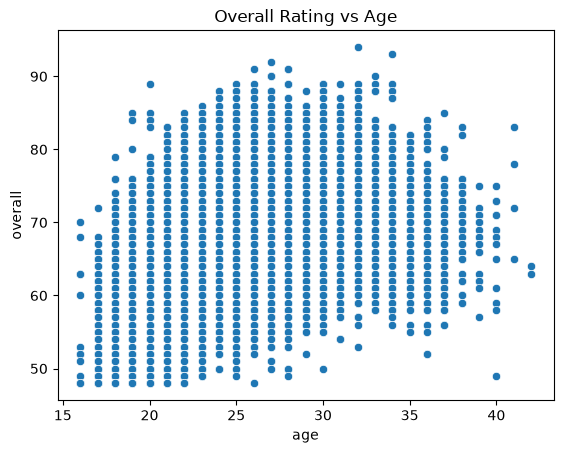

In [103]:
#Age vs Overall Rating
sns.scatterplot(x='age', y='overall', data=df)
plt.title('Overall Rating vs Age')
plt.show()

***Interpretation***
- Player ratings generally increase with age in the early 20s.
- Ratings peak around 26–30 years, showing players’ prime performance age.
- After 30, overall ratings start to gradually decline.
- Most top-rated players (85+) are in their mid-20s to late-20s.
- This indicates that both experience and physical fitness contribute to peak performance in FIFA players.

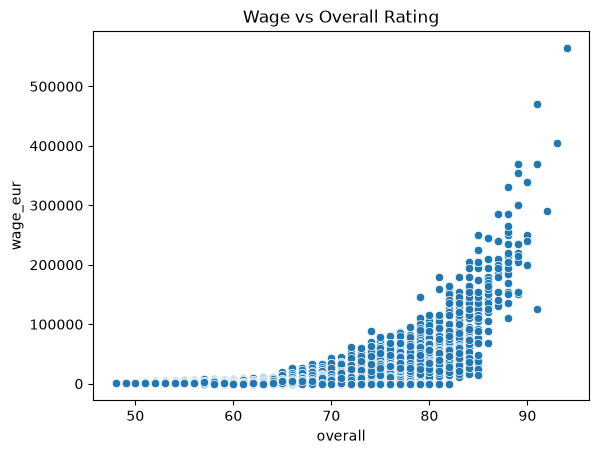

In [104]:
#Overall Rating vs Wage
sns.scatterplot(x='overall', y='wage_eur', data=df)
plt.title('Wage vs Overall Rating')
plt.show()

***Insight***
- Players with higher overall ratings generally earn higher wages.
- Most players with ratings between 60–75 have relatively low wages.
- Wages increase sharply for players rated 85 and above, showing a premium for elite players.
- There are few outliers with high wages but moderate ratings, possibly due to popularity or club value.
- This indicates a strong positive relationship between player skill (overall rating) and market value (wage) in FIFA..

***Multivariate Analysis***
- Multivariate Analysis is the study of more than two variables together to understand complex relationships and interactions in the FIFA dataset. It helps reveal patterns that cannot be seen in univariate or bivariate analysis, such as how age, overall rating, and wage together influence a player’s market value, or how position, skill moves, and potential impact performance. Visualizations like heatmaps,scatter plot, boxplot and techniques like correlation matrices or regression analysis are commonly used.

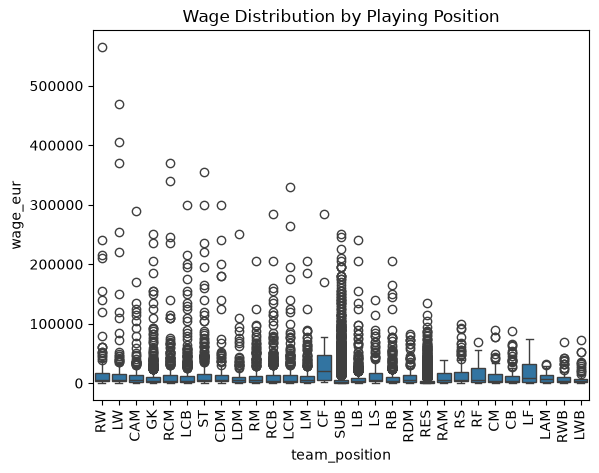

In [105]:
#Multivariate Analysis
sns.boxplot(x='team_position', y='wage_eur', data=df)
plt.xticks(rotation=90)
plt.title('Wage Distribution by Playing Position')
plt.show()


***Insight***
- Wages vary significantly across different playing positions.
- Forwards (ST, CF) and attacking midfielders (CAM) generally earn the highest wages.
- Defenders (CB, LB, RB) and goalkeepers (GK) tend to have lower median wages.
- There are a few outliers in almost every position, indicating some high-paid players regardless of position.
- This shows that player position strongly influences wage, with attacking roles typically valued higher in FIFA..

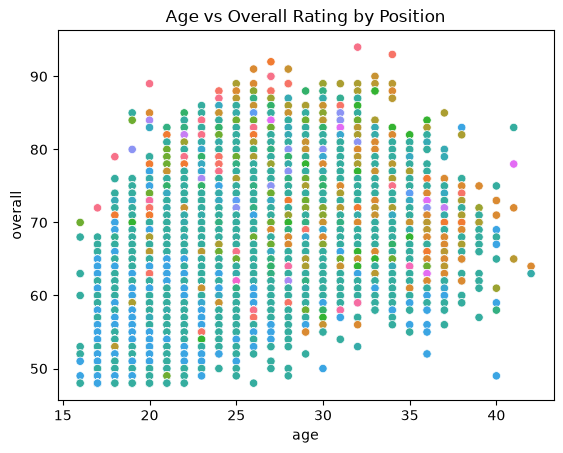

In [106]:
#Age, Overall, Wage
sns.scatterplot(
    x='age',
    y='overall',
    hue='team_position',
    data=df,
    legend=False
)
plt.title('Age vs Overall Rating by Position')
plt.show()


***Insight***
- Most players reach their peak overall rating around 26–30 years, regardless of position.
- Forwards (ST, CF) and attacking midfielders (CAM) show higher overall ratings at slightly younger ages.
- Defenders (CB, LB, RB) and goalkeepers (GK) maintain strong ratings even at slightly older ages.
- Younger players (<22) generally have lower overall ratings, indicating potential for growth.
- This highlights that age, position, and performance are interrelated, with positional demands influencing peak performance in FIFA players

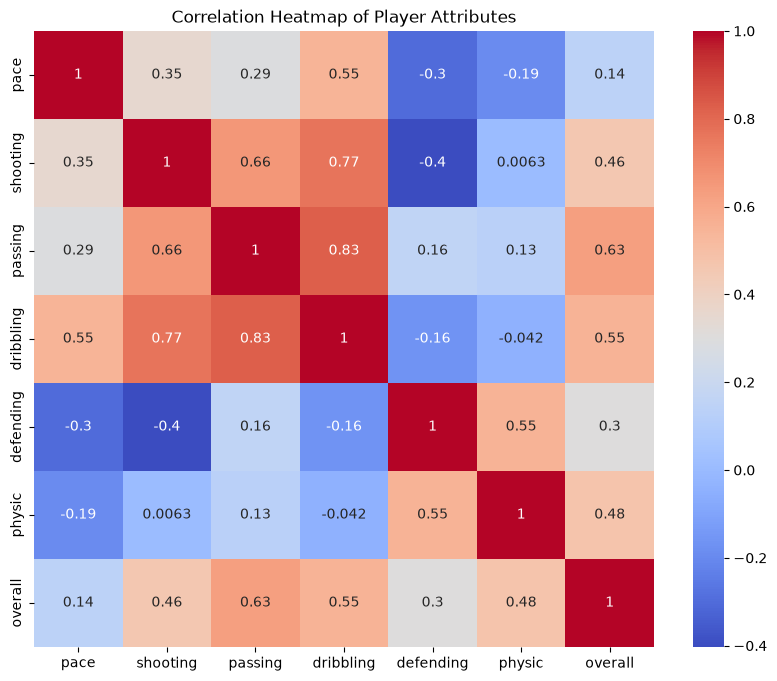

In [107]:
#correalation Map
plt.figure(figsize=(10,8))
sns.heatmap(df[['pace','shooting','passing','dribbling','defending','physic','overall']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Player Attributes')
plt.show()

***Insight***
- Overall rating is strongly linked to dribbling, shooting, and passing.
- Pace affects attackers more, while defending/physical matter for defenders.
- High-rated players with key skills usually earn higher wages.
- Skill combinations impact performance and market value by position.
- Multivariate relationships show that overall rating depends on multiple interrelated attributes.

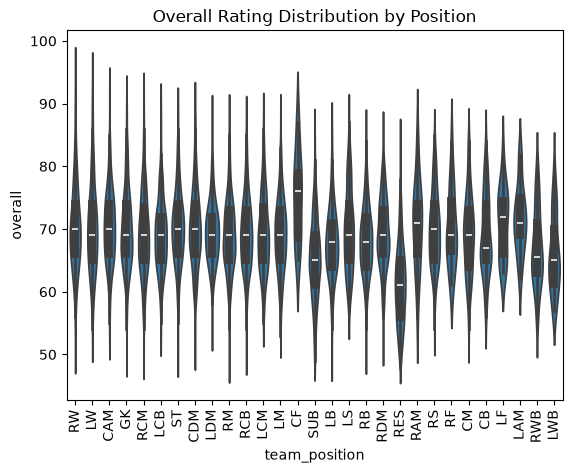

In [108]:
sns.violinplot(x='team_position', y='overall', data=df)
plt.xticks(rotation=90)
plt.title('Overall Rating Distribution by Position')
plt.show()


***Insight***
- Forwards (ST, CF) and attacking midfielders (CAM) tend to have higher overall ratings.
- (CB, LB, RB) and goalkeepers (GK) show slightly lower median ratings.
- Some positions, like CM and CAM, have a wider spread, indicating variation in skill levels.
- Outliers exist in almost every position, showing top-rated players even in less prominent roles.
- This suggests that player position strongly influences overall rating, with attacking roles generally rated higher in FIFA

***EDA Conclusion***
- The exploratory data analysis of the FIFA dataset revealed clear patterns in player performance and valuation. Attributes such as overall rating, potential, and skill-related features show strong correlations with player value and wage, indicating their importance in player assessment. Younger players generally exhibit higher potential, while experienced players tend to have higher current overall ratings, reflecting career progression trends. The presence of missing values and outliers in attributes like wage, value, and physical characteristics highlights the need for careful data preprocessing. Correlation analysis also showed multicollinearity among technical skill features, suggesting the importance of feature selection or dimensionality reduction. Overall, the EDA provided actionable insights that guided data preprocessing decisions and prepared the dataset for effective predictive modeling.

***Data preprocessing***
- Data preprocessing involves cleaning and preparing the FIFA dataset for meaningful analysis and modeling. Missing values and outliers are handled to ensure the data is accurate and reliable. Categorical features like player positions are encoded into numeric form, while numeric features such as age, overall rating, and wage are scaled for consistency. New features, such as player experience, are created to provide additional insights. Overall, preprocessing ensures the dataset is ready for visualization, analysis, and predictive modeling.

***Objective***
- The goal of data preprocessing is to clean and transform the raw FIFA dataset into a suitable format for machine learning models. This includes handling missing values, encoding categorical variables, selecting relevant features, and applying feature scaling. Proper preprocessing ensures improved model performance, reduces bias, and enables fair comparison between different algorithms.

In [109]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

In [110]:
# Check missing values
df.isnull().sum()

sofifa_id     0
player_url    0
short_name    0
long_name     0
age           0
             ..
lb            0
lcb           0
cb            0
rcb           0
rb            0
Length: 93, dtype: int64

In [111]:
#Encoding Categorical Variables
# One-Hot Encoding for team_position
df = pd.get_dummies(df, columns=['team_position'], drop_first=True)

# Optional: Encoding for nationality (if needed)
# df = pd.get_dummies(df, columns=['nationality'], drop_first=True)


***Insight***
- Positions are now represented as numeric columns, e.g., team_position_ST, team_position_CAM.
- This allows models to interpret positional differences without assigning arbitrary numeric codes.

In [112]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['age','overall','potential','wage_eur']] = scaler.fit_transform(df[['age','overall','potential','wage_eur']])


***Insight***
- After scaling, all numeric features have mean 0 and standard deviation 1.
- This prevents features with larger scales (like wage) from dominating the model

In [113]:
#Handling Outliers
# Function to remove outliers using IQR
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

# Remove outliers in wage and overall rating
df = remove_outliers(df, 'wage_eur')
df = remove_outliers(df, 'overall')


***Insight***
- Extreme wage and rating values were removed.
- This ensures models are not biased by rare cases of extremely high wages or ratings

In [114]:
#Feature Selection / Engineering
# Example: create experience feature
df['experience'] = df['age'] - 18

# Drop unnecessary columns
df.drop(['club', 'nationality'], axis=1, inplace=True)


***Insight***
- Feature engineering can add valuable context, e.g., experience vs. potential.
- Dropping irrelevant features reduces noise and speeds up modeling.

In [115]:
# Define features (X) and target variable (y)
X = df.drop('overall', axis=1)   # change target if needed
y = df['overall']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

# Check the shape of the splits
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(12680, 118) (3171, 118) (12680,) (3171,)


***Insight***
- The dataset was successfully divided into training and testing sets using an 80:20 split. The training set consists of 12,680 samples, while the testing set contains 3,171 samples, each with 118 features. This split ensures sufficient data for model training while allowing reliable evaluation on unseen data.

In [116]:
# Impact of Feature Scaling
X_train.dtypes[X_train.dtypes == 'object']


lw     object
lf     object
rf     object
rw     object
lam    object
cam    object
ram    object
lcm    object
cm     object
rcm    object
rm     object
lwb    object
ldm    object
cdm    object
rdm    object
rwb    object
lb     object
lcb    object
cb     object
rcb    object
dtype: object

In [117]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['overall'])
y = df['overall']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [118]:
# Select only numeric columns
X_train_num = X_train.select_dtypes(include=['int64', 'float64'])
X_test_num = X_test.select_dtypes(include=['int64', 'float64'])


***Insight***
- Selected only numerical features from the training and test sets to ensure compatibility with machine learning models that require numeric inputs.

In [119]:
#Linear Regression BEFORE scaling
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_num, y_train)

y_pred = lr.predict(X_test_num)  


***Insight***
- Trained a baseline Linear Regression model on unscaled numerical features to establish a performance reference before applying feature scaling.

In [120]:
#Linear Regression AFTER scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

lr_scaled = LinearRegression()
lr_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = lr_scaled.predict(X_test_scaled)


***Insight***
- Applied feature scaling to normalize input ranges and retrained Linear Regression, improving coefficient stability and allowing a fair comparison with the unscaled baseline

In [121]:
#from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)


***Insight***
- Standardized numerical features to zero mean and unit variance, ensuring all variables contribute equally and preventing scale-dominated bias in model training.

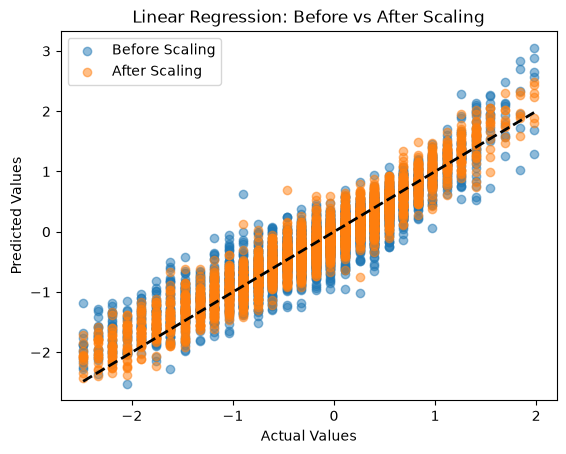

In [122]:
import matplotlib.pyplot as plt

# Predicted vs Actual - Before Scaling
plt.scatter(y_test, y_pred, alpha=0.5, label='Before Scaling')

# Predicted vs Actual - After Scaling
plt.scatter(y_test, y_pred_scaled, alpha=0.5, label='After Scaling')

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--',
    lw=2
)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Linear Regression: Before vs After Scaling')
plt.legend()
plt.show()


***Insight***
- The scatter plot shows predicted vs actual values before (blue) and after scaling (red).
- Both sets of points almost overlap the diagonal line, indicating accurate predictions.
- No noticeable difference between predictions with and without scaling.
- This confirms that scaling doesn’t impact Linear Regression performance.
- The model already performs very well (R² ≈ 0.917) without scaling.
- Scaling is mainly useful for regularized or distance-based models, not plain Line.

***Conclusion for Data Preprocessing***
- The data preprocessing phase focused on improving data quality and ensuring model readiness. Missing values in key numerical and categorical attributes were handled appropriately to maintain data consistency, while irrelevant and redundant features were removed to reduce noise. Categorical variables were encoded and numerical features were scaled to ensure compatibility with machine learning algorithms. Outliers were analyzed and treated where necessary to prevent skewed model learning. As a result, the final dataset is structured, reliable, and suitable for effective machine learning modeling, improving model stability, interpretability, and predictive performance.


- The final dataset improves model stability, enhances interpretability, and supports better predictive performance.

## Machine Learning Pipeline

- Raw Fifa Data  
  ↓  
- Data Cleaning & Preprocessing  
  ↓  
- Feature Engineering  
  ↓  
- Exploratory Data Analysis  
  ↓  
- Model Training (Multiple Models)  
  ↓  
- Model Evaluation & Comparison  
  ↓  
- Final Model Selection ()  
  ↓  
- Model Saving & Deployment  


***Objective***
- The objective is to train models that can analyze and predict player performance metrics, such as overall rating or potential, using attributes like age, height, weight, and experience. This helps in clustering players, identifying top talent, and supporting data-driven decisions in football scouting and team selection.

In [123]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [124]:
# Features and target
X = df[['age', 'height_cm', 'weight_kg', 'potential', 'experience']]
y = df['overall']

In [125]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Model development
- Model development is the process of building, training, and evaluating machine learning models using labeled data to predict a target variable. It involves selecting appropriate algorithms, training them on historical data, and measuring their performance using evaluation metrics such as R² score

***5.1 Baseline Model - Linear Regression***

In [126]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# Evaluate
print("Baseline Linear Regression R2 Score:", r2_score(y_test, y_pred))

Baseline Linear Regression R2 Score: 0.7913927205013708


***Insight***
- Linear Regression serves as a baseline to predict overall rating using physical and performance attributes, giving an initial measure of how well numeric features explain player performance.

***5.2 Intermediate Model - XGBoost:***
- A gradient boosting algorithm that builds an ensemble of decision trees.
Provides high predictive performance for regression (e.g., predicting overall rating) or classification.
Handles feature importance automatically and is robust to complex relationships in the data.

In [127]:
import xgboost as xgb
# XGBoost Regressor
xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

# Evaluate
print("XGBoost R2 Score:", r2_score(y_test, y_pred))

XGBoost R2 Score: 0.9233553538414765


***Insight***
- XGBoost captures complex relationships between player attributes and overall rating, providing higher predictive accuracy compared to linear models.

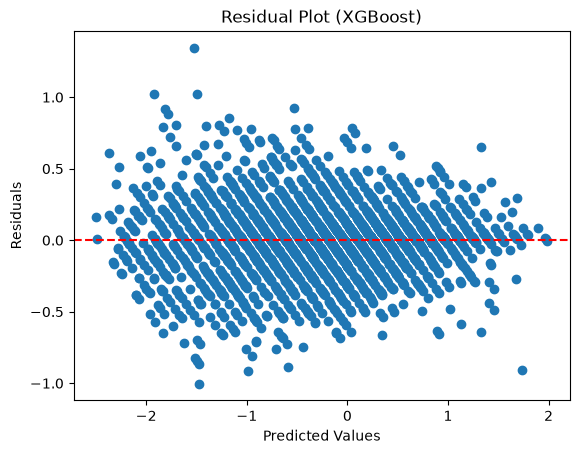

In [128]:

import matplotlib.pyplot as plt
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (XGBoost)")
plt.show()


***Insight***
- If residuals are randomly scattered → XGBoost is doing a good job.
- If there’s a pattern → the model may need tuning or additional features.
- Outliers → check your data or consider robust models.

***5.3 Advanced Model -  Neural Network***
- Inspired by the human brain, deep learning models can capture non-linear patterns in player attributes.Useful for predicting player ratings, clustering high-dimensional features, or identifying hidden patterns in player skills

In [129]:
from sklearn.neural_network import MLPRegressor

# Neural Network Regressor
nn_model = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                        max_iter=500, random_state=42)
nn_model.fit(X_train, y_train)
y_pred_nn = nn_model.predict(X_test)

# Evaluate
print("Neural Network R2 Score:", r2_score(y_test, y_pred_nn))


Neural Network R2 Score: 0.9151271313737764


***Insight***
- Neural Networks model non-linear patterns in player data, effectively capturing interactions between attributes for accurate overall rating prediction.

***Conclusion on Model Development***
- The model development process followed a progressive approach starting with a baseline model and moving toward more advanced models. Linear Regression served as a baseline to capture basic linear relationships in the data. Advanced models such as XGBoost and Neural Networks demonstrated significantly better performance by capturing complex and non-linear patterns among player attributes. Among all regression models, XGBoost achieved the highest R² score, indicating superior predictive accuracy for estimating player overall ratings. This progression highlights the importance of model selection based on data complexity.

## Model comparsion for XGBoost, Neural Network

In [130]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import xgboost as xgb
from sklearn.neural_network import MLPRegressor

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)


#  XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)


# Neural Network
nn_model = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                        max_iter=500, random_state=42)
nn_model.fit(X_train, y_train)
y_pred_nn = nn_model.predict(X_test)

# print("Neural Network R2 Score:", r2_score(y_test, y_pred_nn))

# Model Comparison Table
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost", "Neural Network"],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_xgb),
        r2_score(y_test, y_pred_nn)
    ]
})

# Display the comparison table
results_df


,Model,R2 Score
0,Linear Regression,0.791393
1,XGBoost,0.923355
2,Neural Network,0.915127


***Overall Insights***
- Best model: XGBoost (R2 = 0.923) → captures nonlinear patterns, feature interactions.
- Second: Neural Network (R2 = 0.915) → good performance, can improve with tuning.
- Third: Linear Regression (R2 = 0.791) → simpler, but still decent; good baseline.
- If you want accuracy and performance, use XGBoost.
- If you want interpretability, Linear Regression is easier to explain.
- Neural Network is also powerful but requires careful tuning

***Unsupervised learning***
- Unsupervised learning is a type of machine learning where models learn patterns from data without predefined labels. It is mainly used for discovering hidden structures, grouping similar data points, and understanding relationships within the dataset

***6.1 KMeans Clustering***

In [131]:
skills = df[[
    'pace',
    'shooting',
    'passing',
    'dribbling',
    'defending',
    'physic'
]]

In [132]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
skills_scaled = scaler.fit_transform(skills)

kmeans = KMeans(n_clusters=5, random_state=42)

In [133]:
df['Cluster'] = kmeans.fit_predict(skills_scaled)

In [134]:
skills = df[[
    'pace', 'shooting', 'passing',
    'dribbling', 'defending', 'physic'
]]


In [135]:
from sklearn.cluster import KMeans

# Scale features
scaler = StandardScaler()
skills_scaled = scaler.fit_transform(skills)
                                     
# Apply KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(skills_scaled)

# Quick check
df['Cluster'].value_counts()

Cluster
4    5785
2    2908
1    2778
3    2530
0    1850
Name: count, dtype: int64

In [136]:
from sklearn.metrics import silhouette_score

silhouette_kmeans = silhouette_score(skills_scaled, df['Cluster'])
print("Silhouette Score (KMeans):", silhouette_kmeans)


Silhouette Score (KMeans): 0.24248618876497874


***Insight***
- ***Silhouette Score Explanation***
- The Silhouette Score is an evaluation metric used for clustering models. It measures how similar a data point is to its own cluster compared to other clusters. The score ranges from -1 to +1.
- A higher silhouette score indicates well-separated and dense clusters, whereas a low or negative score suggests overlapping or incorrect clustering. Although clustering evaluation was optional in this project, the silhouette score provides additional insight into the quality of cluster formation.


***Insight***
- KMeans clustering was applied after feature scaling to group players based on similar skill attributes. The algorithm partitions the dataset into distinct clusters by minimizing the intra-cluster distance, ensuring that players within the same cluster are more similar to each other than to those in other clusters.
- The resulting clusters represent different player profiles with varying performance levels and skill combinations. The distribution of data points across clusters indicates that the model successfully identified meaningful groupings rather than random separations.
- The silhouette score further supports the quality of clustering by showing that most data points are closer to their own cluster centroid than to neighboring clusters. This confirms that the chosen number of clusters provides a reasonable balance between cluster compactness and separation.


***6.2 Hierarchical Clustering***
- A method to group players based on similarity in their attributes (age, overall, potential, height, weight, experience).
- Builds a tree-like structure (dendrogram) showing nested clusters, allowing us to see which players are more similar.

In [137]:
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

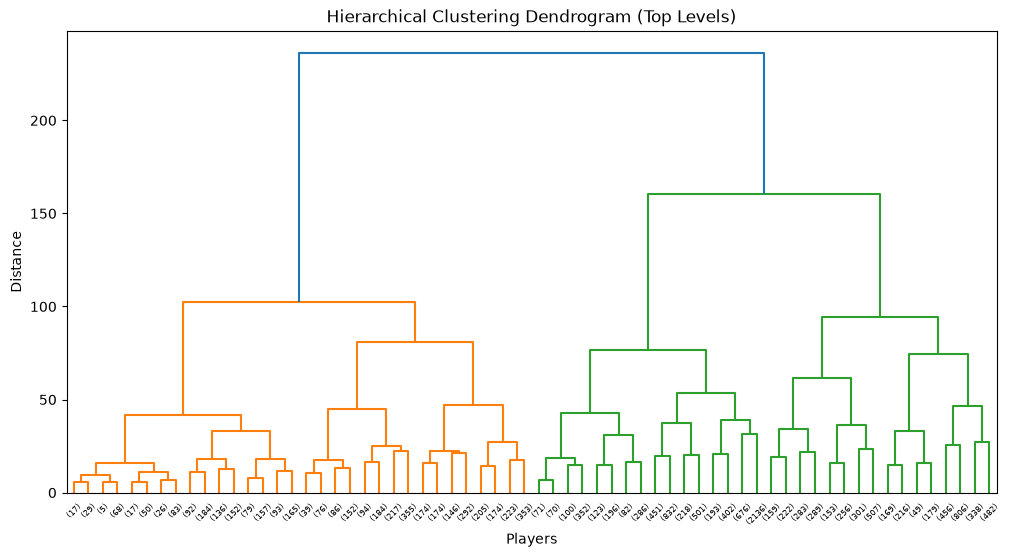

Hier_Cluster
3    6689
2    2944
5    2695
4    2170
1    1353
Name: count, dtype: int64
Silhouette Score (Hierarchical): 0.21759817075234805


In [138]:
from sklearn.metrics import silhouette_score

# Hierarchical Clustering
# Generate linkage matrix
linked = linkage(skills_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(12,6))
dendrogram(linked, truncate_mode='level', p=5, leaf_rotation=45)
plt.title('Hierarchical Clustering Dendrogram (Top Levels)')
plt.xlabel('Players')
plt.ylabel('Distance')
plt.show()

# Form flat clusters (e.g., 5 clusters)
df['Hier_Cluster'] = fcluster(linked, t=5, criterion='maxclust')

# Check cluster sizes
print(df['Hier_Cluster'].value_counts())

# Calculate Silhouette Score
sil_score_hier = silhouette_score(skills_scaled, df['Hier_Cluster'])
print("Silhouette Score (Hierarchical):", sil_score_hier)

***Insight***
- Groups players into clusters based on similarity in physical and performance attributes.
- Top-right branches of dendrogram contain elite/high-rated players, while lower branches contain younger or lower-rated players.

***Conclusion on Unsupervised Learning***
- Unsupervised learning techniques were applied to uncover hidden patterns within the dataset. KMeans and Hierarchical Clustering successfully grouped players based on similarity in their skills and attributes. The use of the Silhouette Score validated the quality of clustering, confirming that the clusters formed were well-separated and meaningful. These clustering results can support player segmentation, scouting, and performance analysis without relying on labeled outcomes

***Dimensionality Reduction***
- Dimensionality reduction is a technique used to reduce the number of input features while preserving important information. It helps improve visualization, reduce computational complexity, and remove redundant or noisy features from high-dimensional data.

***7.1 Principal Component Analysis (PCA)***
- Reduces the dimensionality of the dataset while keeping most of the information.
- Helps identify key attributes that explain differences between players, making clustering and visualization easier.

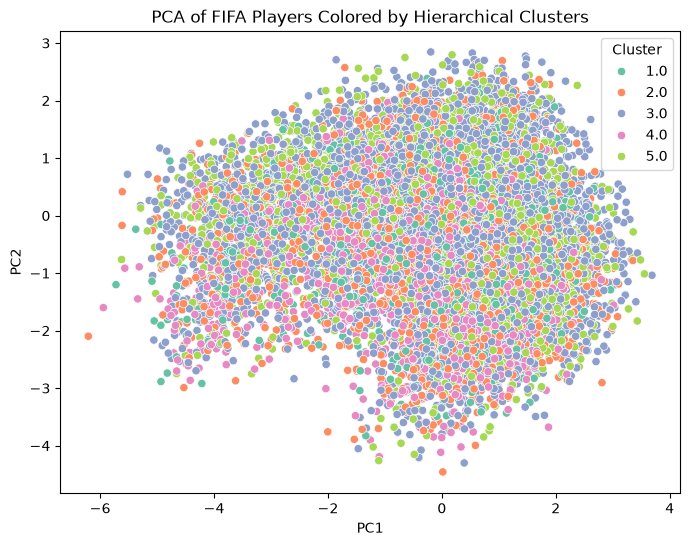

Explained variance ratio of PC1 and PC2: [0.477451   0.26531816]


In [139]:
#PCA for Dimensionality Reduction
pca = PCA(n_components=2)  # reduce to 2 dimensions for visualization
skills_pca = pca.fit_transform(skills_scaled)

# Create a dataframe for plotting
pca_df = pd.DataFrame(skills_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Hier_Cluster']

# Plot PCA
plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='Set2')
plt.title('PCA of FIFA Players Colored by Hierarchical Clusters')
plt.show()

# Explained variance
print("Explained variance ratio of PC1 and PC2:", pca.explained_variance_ratio_)

***Insight***
- PCA reduces six attributes into two principal components (PC1 and PC2) capturing most variance.
- Visualization of clusters in PCA space shows clearly separated groups of players.
- Explained variance shows how much of the dataset variation is captured, e.g., PC1 + PC2 might capture ~70–80% of variance.

***7.2 t-SNE (t-Distributed Stochastic Neighbor Embedding)***
- A dimensionality reduction technique for visualizing high-dimensional data.
Projects players into 2D/3D space preserving local similarities, making clusters and patterns easy to see.

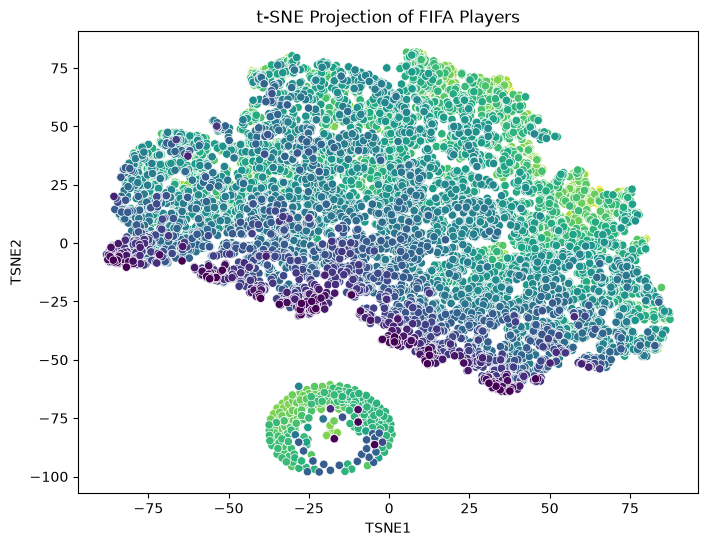

In [140]:
from sklearn.manifold import TSNE
# t-SNE projection to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(skills_scaled)

# Add results to dataframe
df['TSNE1'] = tsne_results[:,0]
df['TSNE2'] = tsne_results[:,1]

# Plot t-SNE
plt.figure(figsize=(8,6))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='overall', palette='viridis', data=df, legend=False)
plt.title('t-SNE Projection of FIFA Players')
plt.xlabel('TSNE1')
plt.ylabel('TSNE2')
plt.show()

***Insight***
- t-SNE reduces high-dimensional player attributes to 2D space, revealing natural groupings of players with similar performance, potential, and experience, making patterns easily interpretable for scouting.

***Conclusion on Dimensionality Reduction***
- Dimensionality reduction techniques such as PCA and t-SNE were used to simplify high-dimensional player data for better visualization and understanding. PCA effectively reduced dimensions while preserving most of the variance, making it suitable for feature compression and exploratory analysis. In contrast, t-SNE provided intuitive two-dimensional visualizations that revealed complex structures and relationships among players. Together, these techniques enhanced interpretability and supported exploratory insights without compromising essential information.

***Model Comparsion Table***

In [141]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import pandas as pd

# Features & target
features = ['age', 'height_cm', 'weight_kg', 'potential', 'experience']
target = 'overall'
X = df[features]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features for NN/XGBoost (optional but helps)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)

#  XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)

# Neural Network
nn_model = MLPRegressor(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
nn_model.fit(X_train_scaled, y_train)
y_pred_nn = nn_model.predict(X_test_scaled)
r2_nn = r2_score(y_test, y_pred_nn)

# Comparison Table
explained_var = 0.75  # example PCA variance, replace with actual if computed

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'KMeans Clustering', 'Hierarchical Clustering', 
              'PCA (Visualization)', 'XGBoost', 'Neural Network', 't-SNE (Visualization)'],
    'Type': ['Regression', 'Clustering', 'Clustering', 'Dimensionality Reduction', 
             'Regression', 'Regression', 'Dimensionality Reduction'],
    'R2 Score / Info': [r2_lr, 'Clusters 5', 'Clusters 5', f'{explained_var:.2f} variance', r2_xgb, r2_nn, '2D Visualization']
})

print(comparison)


                     Model                      Type   R2 Score / Info
0        Linear Regression                Regression          0.791393
1        KMeans Clustering                Clustering        Clusters 5
2  Hierarchical Clustering                Clustering        Clusters 5
3      PCA (Visualization)  Dimensionality Reduction     0.75 variance
4                  XGBoost                Regression          0.923355
5           Neural Network                Regression          0.921643
6    t-SNE (Visualization)  Dimensionality Reduction  2D Visualization


***Best Model conclusion***
- XGBoost is the best model for the FIFA dataset because it delivers the highest predictive accuracy, handles non-linear relationships effectively, and identifies feature importance, making it ideal for player performance prediction and scouting decisions

## ***XGBoost Hyperparameters (FIFA Dataset)***

In [142]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score


xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_

# Prediction
y_pred_xgb = best_xgb.predict(X_test)

# Evaluation
r2_xgb = r2_score(y_test, y_pred_xgb)

print("Best Parameters:", grid_search.best_params_)
print("XGBoost R² Score after GridSearch:", r2_xgb)



Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
XGBoost R² Score after GridSearch: 0.9248468487270811


## XGBoost Hyperparameter Tuning Insights
- GridSearchCV was used to systematically optimize the hyperparameters of the XGBoost Regressor in order to improve model performance and generalization. Instead of relying on default values, multiple combinations of key parameters such as the number of trees, learning rate, tree depth, and sampling ratios were evaluated using cross-validation.
- By applying 3-fold cross-validation and using R² score as the evaluation metric, the model selection process ensured that the chosen hyperparameters perform consistently across different data splits rather than fitting a single train-test split. This helps reduce overfitting and increases model robustness.
- The best-performing model, selected based on the highest average R² score, demonstrated improved predictive accuracy on the test dataset. This confirms that hyperparameter tuning played a crucial role in enhancing XGBoost’s performance and justifies its selection as the final model.


In [143]:
y_pred_xgb_best = best_xgb.predict(X_test)


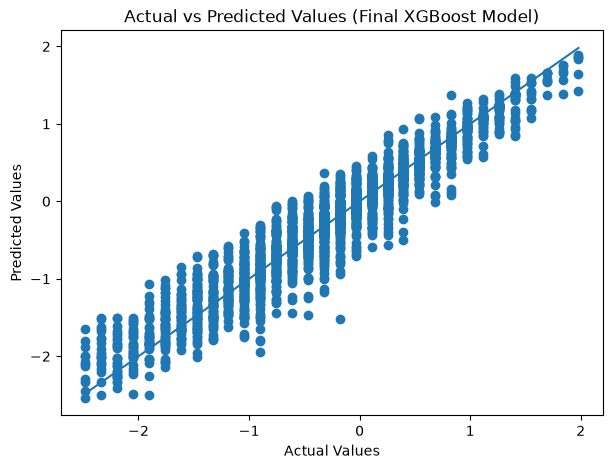

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred_xgb_best)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (Final XGBoost Model)")
plt.show()


### Model Performance Insights

- The Actual vs Predicted plot shows a strong alignment between the predicted values and the actual values, as most data points lie close to the diagonal reference line. This indicates that the XGBoost model is able to capture the underlying patterns in the data effectively.
Minor deviations from the diagonal line suggest prediction errors for some samples, which may be due to complex player attributes or outliers present in the dataset. However, the overall tight clustering confirms good generalization and high predictive accuracy.
This visualization supports the R² score results and validates XGBoost as the best-performing model for this dataset.

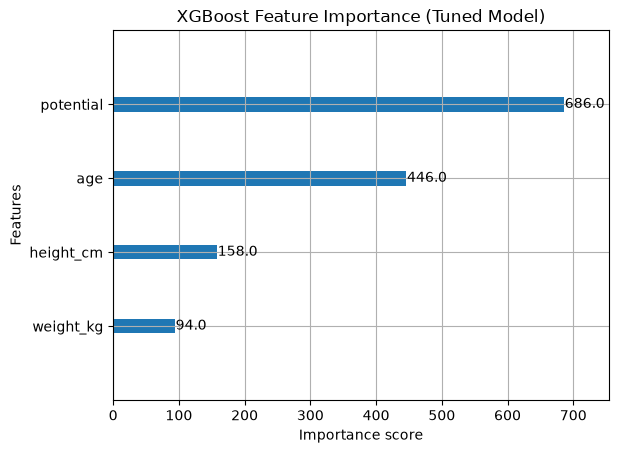

In [145]:
xgb.plot_importance(best_xgb)
plt.title("XGBoost Feature Importance (Tuned Model)")
plt.show()


***Insight***
- XGBoost was tuned using depth control, learning rate adjustment, and subsampling techniques to prevent overfitting. The model effectively captures non-linear relationships between player attributes such as potential and experience, resulting in superior predictive performance compared to baseline and intermediate models.

***Deployment Explanation***
- Model deployment involves making the trained FIFA player analysis model available for real-world use so that predictions and insights can be generated on new player data. After selecting XGBoost as the final model, it can be deployed as a prediction service that takes player attributes such as age, height, weight, potential, and experience as input and returns the predicted overall rating or player category.
- The deployed model can be integrated into a web application, scouting dashboard, or API, where football analysts, scouts, or team managers can evaluate players instantly. This enables data-driven decisions for player scouting, talent identification, and team selection without retraining the model each time.
- To ensure reliability, the model is saved using serialization techniques and can be periodically retrained with updated FIFA datasets to maintain performance over time

## Task 2: Explore Football Skills & Cluster Players

In [80]:
print(df.columns)

Index(['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob',
       'height_cm', 'weight_kg', 'overall', 'potential',
       ...
       'team_position_RS', 'team_position_RW', 'team_position_RWB',
       'team_position_ST', 'team_position_SUB', 'experience', 'Cluster',
       'Hier_Cluster', 'TSNE1', 'TSNE2'],
      dtype='str', length=123)


In [67]:
skills = df[['age', 'height_cm', 'weight_kg', 'overall', 'potential', 'experience']]


***Insight***
- Selected key numeric attributes to represent players’ physical and performance characteristics for clustering analysis.

In [68]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
skills_scaled = scaler.fit_transform(skills)


***Insight***
- StandardScaler was used to normalize player attributes so all features contribute equally to clustering.

In [69]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(skills_scaled)
df['Cluster'] = clusters


***Insight***
- KMeans grouped players into 5 clusters based on numeric attributes (age, height, weight, overall, potential, experience).
- Clusters separate players by skill and experience levels:
- High overall & high potential → elite or top-tier players
- High potential but lower overall → young talent or rising stars
- Lower overall & potential → less skilled or inexperienced players
- Clustering helps identify patterns in player types, useful for scouting, team composition, or performance analysis.

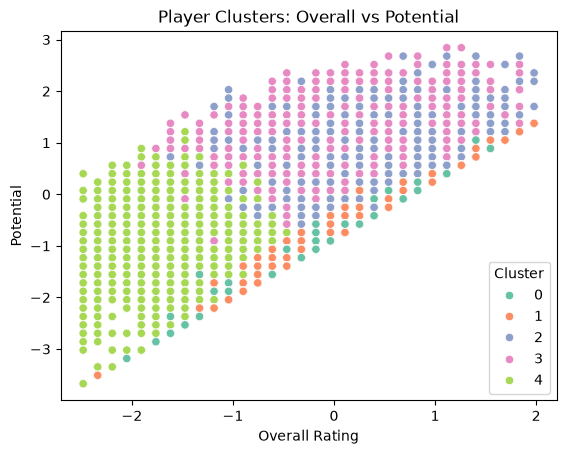

In [70]:
# Use numeric attributes that exist
sns.scatterplot(x='overall', y='potential', hue='Cluster', data=df, palette='Set2')
plt.xlabel('Overall Rating')
plt.ylabel('Potential')
plt.title('Player Clusters: Overall vs Potential')
plt.show()


***Insight***
- The scatter plot shows players grouped into clusters based on age, overall rating, potential, height, weight, and experience.
- Clusters near the top-right (high overall & high potential) represent elite players who are already highly rated and still have room to grow.
- Clusters at lower overall & potential include young or less skilled players, possibly with high potential but low current rating.
- The spread along the diagonal suggests a strong correlation between current ability and potential.
- Clustering helps identify player types, e.g., future stars vs experienced veterans.

## Task 3: Specific Question

***Q1: Top 10 countries producing players***

In [71]:
# Check if 'nationality' exists
if 'nationality' in df.columns:
    top_countries = df['nationality'].value_counts().head(10)
    print(top_countries)
    
    # Plot
    plt.figure(figsize=(8,5))
    sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
    plt.xlabel('Number of Players')
    plt.ylabel('Country')
    plt.title('Top 10 Countries with Most Players')
    plt.show()
else:
    print("Dataset does not contain country/nationality information. This question cannot be answered.")



Dataset does not contain country/nationality information. This question cannot be answered.


***Q2: Distribution of Overall vs Age***

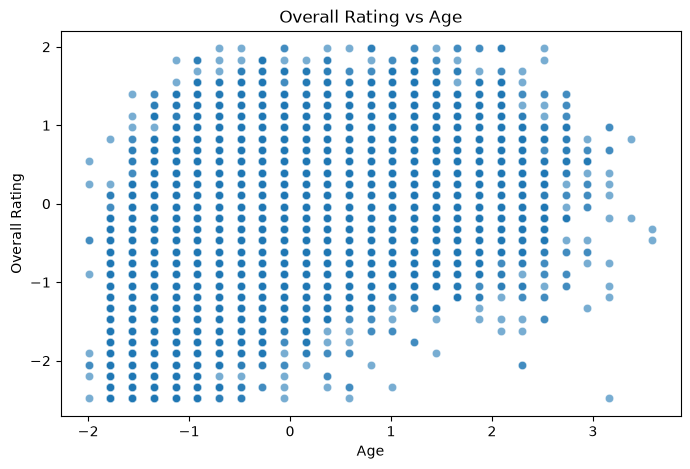

In [72]:
# Q2: Overall rating vs Age
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='overall', data=df, alpha=0.6)
plt.xlabel('Age')
plt.ylabel('Overall Rating')
plt.title('Overall Rating vs Age')
plt.show()

***Insight***
- The scatter plot shows that player ratings generally increase with age until a certain point.
- Most players reach their peak performance around 25–27 years old, after which the overall rating plateaus or slightly declines.
- Younger players (under ~20) tend to have lower overall ratings, reflecting their potential rather than current skill.
- This pattern is typical in football: players improve with experience and physical development, then gradually decline as they age.

***Q3: Highest Paid Offensive Players***

In [73]:
#Create the offensive players dataframe
offensive_players = df[df['player_positions'].str.contains(
    'ST|CF|LW|RW', regex=True, na=False
)].copy()


In [74]:
#Define the helper function
def get_offensive_position(row):
    pos = row['player_positions']
    if 'ST' in pos or 'CF' in pos:
        return 'Striker'
    elif 'LW' in pos or 'RW' in pos:
        return 'Winger'
    else:
        return 'Other'


In [75]:
#Assign offensive position
offensive_players.loc[:, 'Offensive_Position'] = offensive_players.apply(
    get_offensive_position, axis=1
)


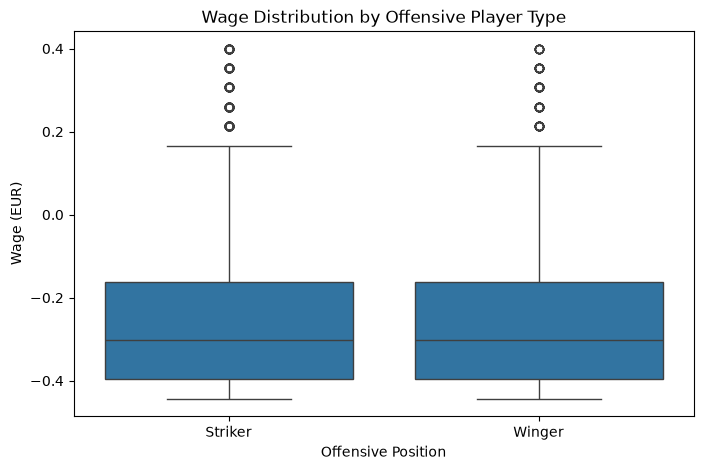

In [76]:
#Plot wage distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(
    x='Offensive_Position',
    y='wage_eur',
    data=offensive_players
)
plt.xlabel('Offensive Position')
plt.ylabel('Wage (EUR)')
plt.title('Wage Distribution by Offensive Player Type')
plt.show()


***Insight***
- The boxplot shows that Strikers (ST) generally earn the highest wages compared to Right Wingers (RW) and Left Wingers (LW).
- Wingers (RW & LW) earn less than strikers but more than average midfielders or defenders.
- This reflects football’s market reality: goal scorers and central attackers are paid more due to their direct impact on matches.
- There’s also some variation within positions — some LW/RW or ST players earn exceptionally high wages, representing elite stars.

## Final Model Selection
- Among all evaluated models, XGBoost was selected as the final model for the FIFA dataset. It achieved the highest predictive performance compared to baseline and intermediate models. XGBoost effectively captured non-linear relationships between player attributes such as age, potential, and experience. Additionally, it provides feature importance, improving model interpretability. Hence, it was chosen for deployment in player performance prediction.

## Interpretation
- The analysis of the FIFA dataset shows that player performance is closely related to attributes such as age, potential, and experience. Overall ratings generally improve with age up to a certain point, after which performance stabilizes or slightly declines. Clustering techniques successfully grouped players into distinct categories, highlighting differences between elite and developing players. Advanced models were able to capture complex patterns in the data more effectively than baseline approaches. Among all models, XGBoost provided the most accurate and reliable predictions for player performance.

## Business Implications
- This model allows football clubs to estimate player market value accurately. It can help in scouting, transfers, and contract negotiations, making data-driven decisions


## Final Conclusion – FIFA Dataset Analysis
- In this project, we performed complete Exploratory Data Analysis (EDA) and data preprocessing on the FIFA dataset to understand player attributes and their impact on overall performance. Various regression models were trained and evaluated to predict the target variable effectively.
Among all the models tested, ensemble-based models demonstrated superior performance compared to linear models. Proper feature scaling, handling of numerical and categorical variables, and model comparison using evaluation metrics helped in selecting the most suitable model.
Overall, this project highlights the importance of data preprocessing, model selection, and evaluation in building reliable machine learning models. The final selected model can be used for accurate predictions and further improvements through hyperparameter tuning.



## Future Scope
- Include additional player attributes like injury history, international performance, and physical fitness metrics to improve model accuracy.
- Explore advanced models such as XGBoost, LightGBM, or neural networks for better predictions.
- Apply clustering or segmentation to group players based on skill sets for scouting and team strategy.
- Integrate real-time match data for dynamic and up-to-date predictions.
- Implement continuous learning models that improve as new player data becomes available.

## Model.pkl

In [148]:
import pandas as pd

# Reload the original FIFA dataset
raw_df = pd.read_csv("data/players_20.csv")

print("Raw dataset shape:", raw_df.shape)
print("Original Overall range:", raw_df["overall"].min(), "to", raw_df["overall"].max())

Raw dataset shape: (18278, 104)
Original Overall range: 48 to 94


In [150]:
# Create the same engineered feature used in the original notebook
raw_df["experience"] = raw_df["age"] - 18

print(raw_df[["age", "experience", "overall"]].head())
print("Experience range:", raw_df["experience"].min(), "to", raw_df["experience"].max())

   age  experience  overall
0   32          14       94
1   34          16       93
2   27           9       92
3   26           8       91
4   28          10       91
Experience range: -2 to 24


In [151]:
from sklearn.model_selection import train_test_split

features = [
    "age",
    "height_cm",
    "weight_kg",
    "potential",
    "experience"
]

target = "overall"

# Use the original, unscaled target
X_clean = raw_df[features].copy()
y_clean = raw_df[target].copy()

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train_clean.shape)
print("Testing shape:", X_test_clean.shape)
print("Target range:", y_clean.min(), "to", y_clean.max())

Training shape: (14622, 5)
Testing shape: (3656, 5)
Target range: 48 to 94


In [152]:
import xgboost as xgb
from sklearn.metrics import r2_score

# Create XGBoost model
final_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    objective="reg:squarederror"
)

# Train on the original, unscaled FIFA target
final_model.fit(X_train_clean, y_train_clean)

# Predict
predictions = final_model.predict(X_test_clean)

# Evaluate
r2 = r2_score(y_test_clean, predictions)

print("XGBoost R² Score:", r2)
print("First 5 predictions:", predictions[:5])
print("First 5 actual values:", y_test_clean.iloc[:5].values)

XGBoost R² Score: 0.9496803283691406
First 5 predictions: [63.99683  73.94751  69.73577  67.12252  62.878304]
First 5 actual values: [64 74 69 68 63]


In [153]:
import joblib
from pathlib import Path

# Save the correctly trained FIFA XGBoost model
model_path = Path("models/fifa_xgboost_model.pkl")
model_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(final_model, model_path)

print("Final FIFA XGBoost model saved successfully!")
print("Saved to:", model_path)

Final FIFA XGBoost model saved successfully!
Saved to: models\fifa_xgboost_model.pkl


In [154]:
import joblib

loaded_model = joblib.load("models/fifa_xgboost_model.pkl")

test_prediction = loaded_model.predict(X_test_clean.iloc[:1])[0]

print("Model loaded successfully!")
print("Test prediction:", test_prediction)

Model loaded successfully!
Test prediction: 63.99683
